In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

In [4]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df_raw = pd.read_csv(url)
df_raw.to_csv('../data/raw/titanic_raw.csv', index=False)

In [8]:
df = df_raw.copy()

# Fix chained assignment warnings
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Feature Engineering
df['Has_Cabin'] = df['Cabin'].notna().astype(int)
df['Family_Size'] = df['SibSp'] + df['Parch'] + 1
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.')

# One-hot encoding
df = pd.get_dummies(df, columns=['Sex', 'Embarked', 'Title'], drop_first=True)

# Drop unnecessary columns
df = df.drop(['Name', 'Ticket', 'Cabin', 'PassengerId'], axis=1)

# Save cleaned dataset
df.to_csv('../data/processed/titanic_cleaned.csv', index=False)

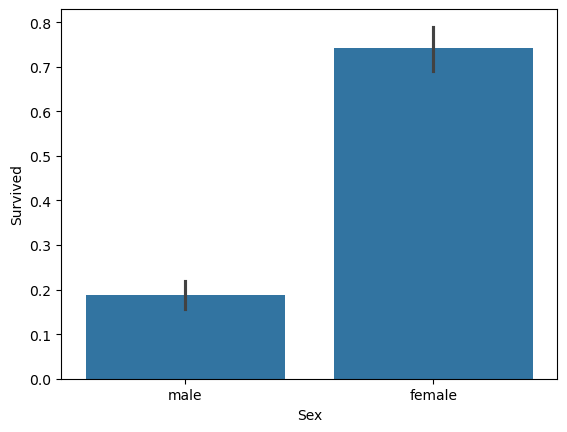

In [11]:
sns.barplot(x='Sex', y='Survived', data=df_raw)
plt.savefig('../figures/survival_by_gender.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

# Decision Tree
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

In [14]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_tree)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_tree)
    ],
    'AUC': [
        roc_auc_score(y_test, log_model.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, tree_model.predict_proba(X_test)[:,1])
    ]
})

results.to_csv('../figures/model_comparison.csv', index=False)
results

,Model,Accuracy,F1-Score,AUC
0,Logistic Regression,0.821229,0.786667,0.887387
1,Decision Tree,0.826816,0.791946,0.832304


In [16]:
import requests

response = requests.get(
    "https://api.open-meteo.com/v1/forecast?latitude=50.9&longitude=-1.4&current=temperature_2m"
)

weather = response.json()
weather

{'latitude': 50.900845,
 'longitude': -1.3883972,
 'generationtime_ms': 0.027894973754882812,
 'utc_offset_seconds': 0,
 'timezone': 'GMT',
 'timezone_abbreviation': 'GMT',
 'elevation': 7.0,
 'current_units': {'time': 'iso8601',
  'interval': 'seconds',
  'temperature_2m': '°C'},
 'current': {'time': '2026-03-02T23:45',
  'interval': 900,
  'temperature_2m': 9.3}}